In [1]:
from astropy import units as u
from astropy.constants import G, c
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import spacehub_calc
from spacehub_calc import TwoBodyOrbit, mag, Theorize
import matplotlib.animation as animation
from IPython.display import HTML
from orbits import distance, get_com, calc_angle
import orbits

### Equations and IC calculations

$M_1 = M_2 = M_3 = 10 M_{\odot}$

$R_1 = R_2 = R_3 = \frac{2GM}{c^2} = \frac{20GM_{\odot}}{c^2}$

$a_0 = 10^{-2}AU$

$r_{start} = 20AU$

$cos(\gamma) = 1$ (co-planar)

$v_{orb}^2 = GM(\frac{2}{r_{12}} - \frac{1}{a_0}) \leftarrow$ (vis-visa, $t=0$)

$v = \frac{v_{\infty}}{v_{orb}\sqrt{3}} = 0.01$

$\rightarrow v_{\inf} = 0.01v_{orb}\sqrt{3} = 0.01\sqrt{3GM(\frac{2}{r_{12}} - \frac{1}{a_0})}$

$b = b_{\inf}/b_{c} = \frac{b_{inf}}{a_0/v}$

$b\in[-4, 4]$

$b_{\inf} = \frac{ba_0}{v}$

$f_{20} \in [0, 2\pi]$

$r_{start} = 20\times a_0$



In [2]:
M = 10 * u.Msun
a0 = 1e-2 * u.AU
r12 = a0 #Because circular orbit
vinf = 0.01 * np.sqrt(  3 * G * M * ( (2/r12) - (1/a0) )    )
vinf.to(u.km / u.s)

<Quantity 16.31374758 km / s>

In [3]:
def b_inf(b, a0, v):
    return b * a0 / (v)

b = np.linspace(-4, 4, 10)
[b_inf(bi, a0, 0.01) for bi in b]

[<Quantity -4. AU>,
 <Quantity -3.11111111 AU>,
 <Quantity -2.22222222 AU>,
 <Quantity -1.33333333 AU>,
 <Quantity -0.44444444 AU>,
 <Quantity 0.44444444 AU>,
 <Quantity 1.33333333 AU>,
 <Quantity 2.22222222 AU>,
 <Quantity 3.11111111 AU>,
 <Quantity 4. AU>]

In [4]:
R_s = 20 * G * u.Msun / c**2

R_s.to(u.Rsun)

<Quantity 4.24500514e-05 solRad>

In [5]:
a0 = a0
e0 = 0
m1, m2 = 10, 10
m1 = m1 * u.Msun
m2 = m2 * u.Msun
beta = (64/5) * G**3 * m1 * m2 * (m1+m2) * c**(-5) #Idk if the c^-5 is supposed to be here, but it fixes the units. G and c are not hard to write. stop using G=C=1
f = Theorize.enhancement_factor(e0)

T = a0**4 / (4*beta*f)
T.to(u.yr)

<Quantity 1605707.13451047 yr>

### Data Processing & Figures

In [6]:
ptc_file = "simulation_results/topology/fig2_ptc.dat"

In [7]:
def load_mt_data(fname):
    
    datain = pd.read_csv(fname, index_col=False)
    data = datain[datain["id"]>=0]
    ics_df = datain[datain["id"]==-2]
    
    # Rename columns for ics_df
    ics_df.columns = ['time', 'id', 'b', 'azi', 'incl', 'ec', 'ci', 'cj', 'n']
    ics_df = ics_df.reset_index()
    #print(data)
    dic = {name: data[name].to_numpy() for name in data.columns}
    particle_num = len(np.unique(dic['id']))
    print(particle_num)

    splited_dic = {}
    splited_dic['time'] = dic['time'][dic['id'] == 0]
    for i in range(particle_num):
        for key in dic.keys():
            if key != 'time' and key != 'id':
                splited_dic[key + str(i)] = dic[key][dic['id'] == i]

    orbits.get_norm(particle_num, splited_dic)

    return ics_df, splited_dic

indf, data = load_mt_data(ptc_file)
indf


3


,index,time,id,b,azi,incl,ec,ci,cj,n
0,3,1.072700,-2,-4.00000,0.000000,0.0,0.0,-1.0,-1.0,0.0
1,7,1.072700,-2,-4.00000,0.021014,0.0,0.0,-1.0,-1.0,0.0
2,11,1.072700,-2,-4.00000,0.042028,0.0,0.0,-1.0,-1.0,0.0
3,15,1.072700,-2,-4.00000,0.063042,0.0,0.0,-1.0,-1.0,0.0
4,19,1.072700,-2,-4.00000,0.084056,0.0,0.0,-1.0,-1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
89995,359983,0.994753,-2,-3.11706,1.996330,0.0,0.0,-1.0,-1.0,0.0
89996,359987,0.994753,-2,-3.11706,2.017340,0.0,0.0,-1.0,-1.0,0.0
89997,359991,0.994753,-2,-3.11706,2.038360,0.0,0.0,-1.0,-1.0,0.0
89998,359995,0.994753,-2,-3.11706,2.059370,0.0,0.0,-1.0,-1.0,0.0


In [8]:
npoints = len(data["time"])
data["ecc01"] = mag(orbits.get_ecc(data, 0, 1))
data["ecc02"] = mag(orbits.get_ecc(data, 0, 2))
data["ecc12"] = mag(orbits.get_ecc(data, 1, 2))
data["rx01"], data["ry01"], data["rz01"] = distance(data, 'p', 0, 1)
data["rx02"], data["ry02"], data["rz02"] = distance(data, 'p', 0, 2)
data["rx12"], data["ry12"], data["rz12"] = distance(data, 'p', 1, 2)

In [ ]:
#outcomes = ["Coll[01]", "Coll[02]", "Coll[12]", "GW[ij]", "BS[01]", "BS[02]", "BS[12]", "VLint", "Failed"] #GW-Coll distinction not yet implemented
result_df = pd.DataFrame(columns=["b", "azi", "incl", "endstate", "ionized", "BC[ijk]", "Coll[ij]", "VLInt", "failed", "rx01", "ry01", "rz01", "rx02", "ry02", "rz02", "rx12", "ry12", "rz12"])
#BC -> bound component
for i in range(0, npoints):
    row = {}
    
    
    #print(f"{data[""]}")
    row["b"] = indf.at[i, "b"]
    row["azi"] = indf.at[i, "azi"]
    row["incl"] = indf.at[i, "incl"]
    if data["time"][i] < 0:
        row["failed"] = 1
        continue
    else:
        row["failed"] = 0

    
    ci = indf.at[i, "ci"]
    cj = indf.at[i, "cj"]
    if (ci < 0):

        Collij = {}
    else:
        Collij = {ci, cj}

    row["ionized"] = 1 if data["ecc01"][i]  >= 1 else 0
    
        
    e_ij = np.array([data["ecc01"][i], data["ecc02"][i], data["ecc12"][i]])
    bound = np.where((e_ij > 0) & (e_ij < 1))[0]
    if len(bound) == 0:
        BCijk = {}
    elif bound[0] == 0:
        BCijk = {0, 1}
    elif bound[0] == 1:
        BCijk = {0, 2}
    elif bound[0] == 2:
        BCijk = {1, 2}
    if len(bound) > 1:
        BCijk = {1, 2, 3}
        row["VLInt"] = True
    
    #----------Precedence: Failed, Collision, (to do GW), BS[ij]/VLInt, 
    if row["failed"] == 1:
        row["endstate"] = "failed"
    
    elif len(Collij) == 2:
        row["endstate"] = "Coll"

    elif len(BCijk) == 2:
        row["endstate"] = "BS[" + str(BCijk)[1:-1].replace(", ","") + "]"

    elif len(BCijk) == 3:
        row["endstate"] = "VLint"

    elif len(BCijk) <= 1:
        row["endstate"] = "?"
    #outcomes = ["Coll[01]", "Coll[02]", "Coll[12]", "GW[ij]", "BS[01]", "BS[02]", "BS[12]", "VLint", "Failed"]
    #add distances in case I want to plot in cartesian
    row["rx01"], row["ry01"], row["rz01"] = data["rx01"][i], data["ry01"][i], data["rz01"][i]
    row["rx02"], row["ry02"], row["rz02"] = data["rx02"][i], data["ry02"][i], data["rz02"][i]
    row["rx12"], row["ry12"], row["rz12"] = data["rx12"][i], data["ry12"][i], data["rz12"][i]
    result_df = pd.concat([result_df, pd.DataFrame(row, index=[len(result_df)])])
        
result_df
    

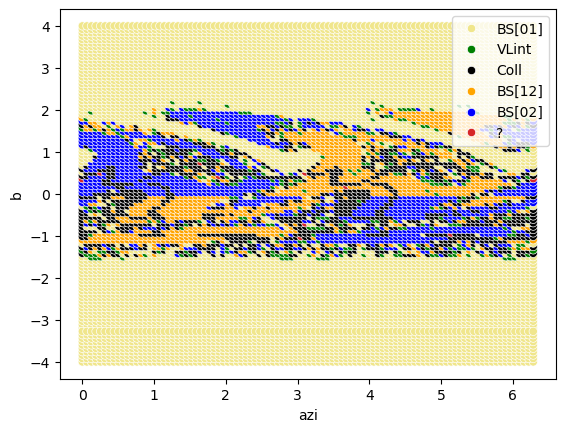

In [ ]:
remove_failed_sims = ~result_df["endstate"].isin(["failed", "?"])
masked_results = result_df[remove_failed_sims]
palette = {
    'VLint': 'green',
    'Coll': 'black',
    'BS[01]': 'khaki',
    'BS[02]': 'blue',
    'BS[12]': 'orange',
    '?':'tab:red'
}

sns.scatterplot(result_df, x='azi', y='b', hue='endstate', palette=palette)
plt.legend(loc='upper right')